In [23]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
sns.set(style="whitegrid")


In [24]:
df = pd.read_csv('SampleSuperstore.csv')

In [25]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [26]:
df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


In [27]:
df.sample(5)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
8284,Second Class,Home Office,United States,Saint Charles,Illinois,60174,Central,Technology,Accessories,637.44,8,0.2,135.4560
5297,Standard Class,Consumer,United States,Yonkers,New York,10701,East,Technology,Phones,543.92,8,0.0,135.9800
2681,Standard Class,Home Office,United States,Jackson,Michigan,49201,Central,Office Supplies,Binders,89.52,4,0.0,42.0744
2259,Second Class,Home Office,United States,San Diego,California,92024,West,Office Supplies,Fasteners,5.00,1,0.0,2.4000
4109,Standard Class,Corporate,United States,Detroit,Michigan,48227,Central,Technology,Phones,73.98,2,0.0,19.9746


Initial Data Exploration 

In [28]:
df.shape

(9994, 13)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [30]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [31]:
df.dtypes

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [32]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [33]:
df.describe(include="object")

,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category
count,9994,9994,9994,9994,9994,9994,9994,9994
unique,4,3,1,531,49,4,3,17
top,Standard Class,Consumer,United States,New York City,California,West,Office Supplies,Binders
freq,5968,5191,9994,915,2001,3203,6026,1523


In [34]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(17)

In [36]:
df.nunique()

Ship Mode          4
Segment            3
Country            1
City             531
State             49
Postal Code      631
Region             4
Category           3
Sub-Category      17
Sales           5825
Quantity          14
Discount          12
Profit          7287
dtype: int64

Data Cleaning 

check for duplicate , dorp , columns that don't add analytical values and sanity-check in numeric fields.

In [37]:
df.duplicated().sum()

np.int64(17)

In [38]:
df= df.drop_duplicates()

In [39]:
df.shape

(9977, 13)

In [40]:
type(df)

pandas.core.frame.DataFrame

In [42]:
# check colums that might not be useful
df['Country'].unique()

array(['United States'], dtype=object)

In [43]:
# drop Country (only 1 unique value) and Postal Code (just an ID, not a numeric feature)
df = df.drop(columns=['Country', 'Postal Code'])
df.columns

Index(['Ship Mode', 'Segment', 'City', 'State', 'Region', 'Category',
       'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [44]:
# sanity check: any zero or negative sales/quantity?
(df['Sales'] <= 0).sum()

np.int64(0)

In [45]:
(df['Quantity']<= 0).sum()

np.int64(0)

In [46]:
# confirm there is no missing values in the dataset
df.isnull().sum()

Ship Mode       0
Segment         0
City            0
State           0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Univariate Analysis 

In [47]:
# Analyze the variable at a time- numeric variables
# Numeric summaries 
df['Sales'].describe()

count     9977.000000
mean       230.148902
std        623.721409
min          0.444000
25%         17.300000
50%         54.816000
75%        209.970000
max      22638.480000
Name: Sales, dtype: float64

In [49]:
df['Profit'].describe()

count    9977.00000
mean       28.69013
std       234.45784
min     -6599.97800
25%         1.72620
50%         8.67100
75%        29.37200
max      8399.97600
Name: Profit, dtype: float64

In [50]:
df['Discount'].describe()

count    9977.000000
mean        0.156278
std         0.206455
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: Discount, dtype: float64

In [51]:
df["Quantity"].describe()

count    9977.000000
mean        3.790719
std         2.226657
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: Quantity, dtype: float64

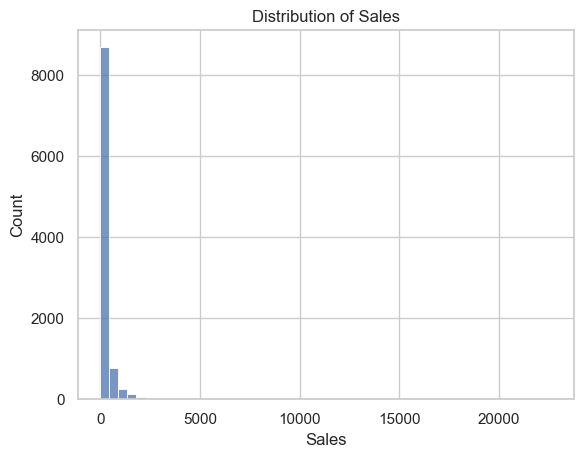

In [53]:
sns.histplot(df["Sales"], bins=50, )
plt.title("Distribution of Sales")
plt.show()

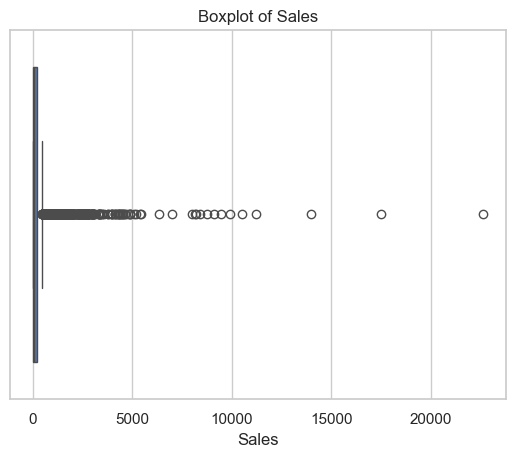

In [55]:
sns.boxplot(x=df["Sales"])
plt.title("Boxplot of Sales")
plt.show()

In [56]:
# categorical value counts
df['Category'].value_counts()


Category
Office Supplies    6012
Furniture          2118
Technology         1847
Name: count, dtype: int64

In [57]:
df['Sub-Category'].value_counts()

Sub-Category
Binders        1522
Paper          1359
Furnishings     956
Phones          889
Storage         846
Art             795
Accessories     775
Chairs          615
Appliances      466
Labels          363
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [58]:
df['Segment'].value_counts()

Segment
Consumer       5183
Corporate      3015
Home Office    1779
Name: count, dtype: int64

In [59]:
df['Ship Mode'].value_counts()


Ship Mode
Standard Class    5955
Second Class      1943
First Class       1537
Same Day           542
Name: count, dtype: int64

In [60]:
df['State'].value_counts().head(10)

State
California        1996
New York          1127
Texas              983
Pennsylvania       586
Washington         502
Illinois           491
Ohio               468
Florida            383
Michigan           254
North Carolina     249
Name: count, dtype: int64

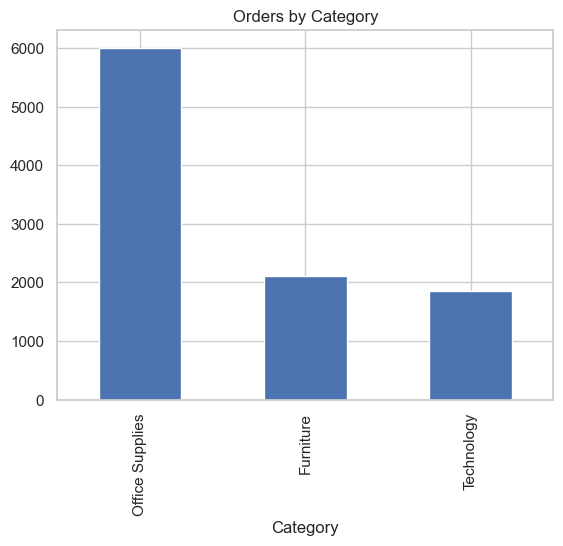

In [61]:
df['Category'].value_counts().plot(kind='bar')
plt.title('Orders by Category')
plt.show()


Bivariate Analysis 

Compare two variables at a time.

In [62]:
# numeric vs numeric
df[['Sales', 'Profit']].corr()


,Sales,Profit
Sales,1.000000,0.479067
Profit,0.479067,1.000000


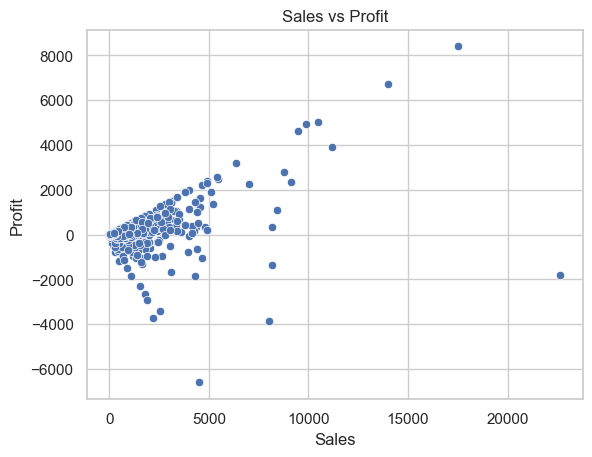

In [63]:
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs Profit')
plt.show()

In [64]:
# categorical vs numeric
df.groupby('Category')['Profit'].sum()

Category
Furniture           18421.8137
Office Supplies    122364.6608
Technology         145454.9481
Name: Profit, dtype: float64

In [65]:
df.groupby('Category')['Sales'].sum()

Category
Furniture          741306.3133
Office Supplies    718735.2440
Technology         836154.0330
Name: Sales, dtype: float64

In [66]:
df.groupby('Region')['Profit'].mean()


Region
Central    17.100421
East       32.163905
South      28.857673
West       33.927281
Name: Profit, dtype: float64

In [67]:
df.groupby('Segment')['Sales'].sum()


Segment
Consumer       1.160833e+06
Corporate      7.060701e+05
Home Office    4.292927e+05
Name: Sales, dtype: float64

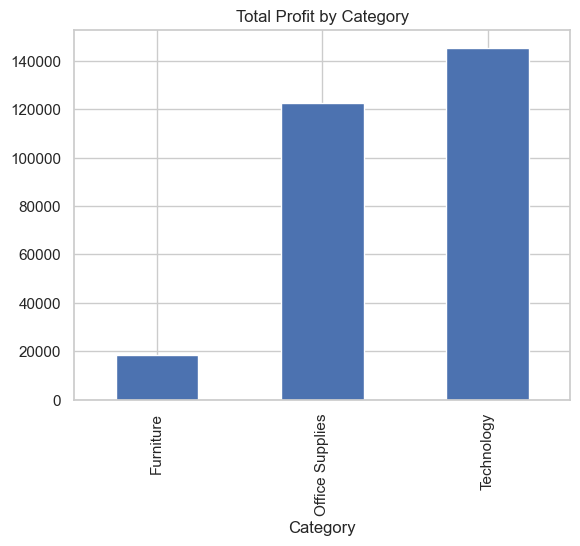

In [68]:
df.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title('Total Profit by Category')
plt.show()

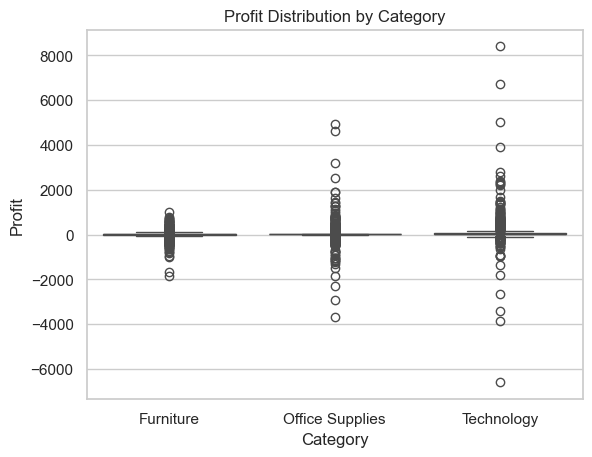

In [69]:
sns.boxplot(x='Category', y='Profit', data=df)
plt.title('Profit Distribution by Category')
plt.show()

Multivariate analysis

Analysis the relationship across  the two or more variables. 


In [70]:
df.groupby(['Category', 'Region'])['Profit'].sum()

Category         Region 
Furniture        Central    -2906.1467
                 East        3058.2246
                 South       6771.2061
                 West       11498.5297
Office Supplies  Central     8864.5899
                 East       40986.0495
                 South      19986.3928
                 West       52527.6286
Technology       Central    33697.4320
                 East       47462.0351
                 South      19991.8314
                 West       44303.6496
Name: Profit, dtype: float64

In [71]:
pd.pivot_table(df, values='Profit', index='Category', columns='Region', aggfunc='sum')


Region,Central,East,South,West
Category,,,,
Furniture,-2906.1467,3058.2246,6771.2061,11498.5297
Office Supplies,8864.5899,40986.0495,19986.3928,52527.6286
Technology,33697.4320,47462.0351,19991.8314,44303.6496


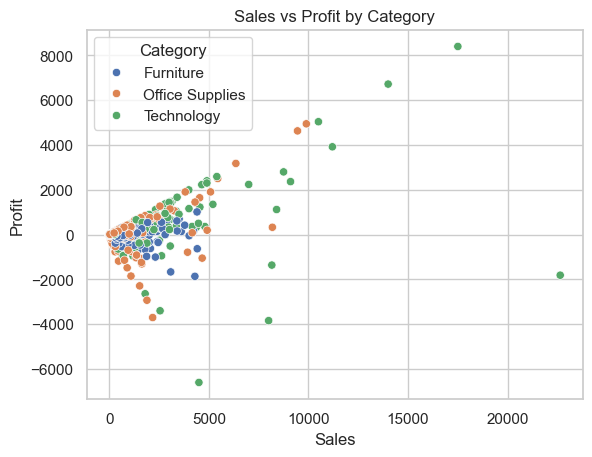

In [72]:
sns.scatterplot(x='Sales', y='Profit', hue='Category', data=df)
plt.title('Sales vs Profit by Category')
plt.show()

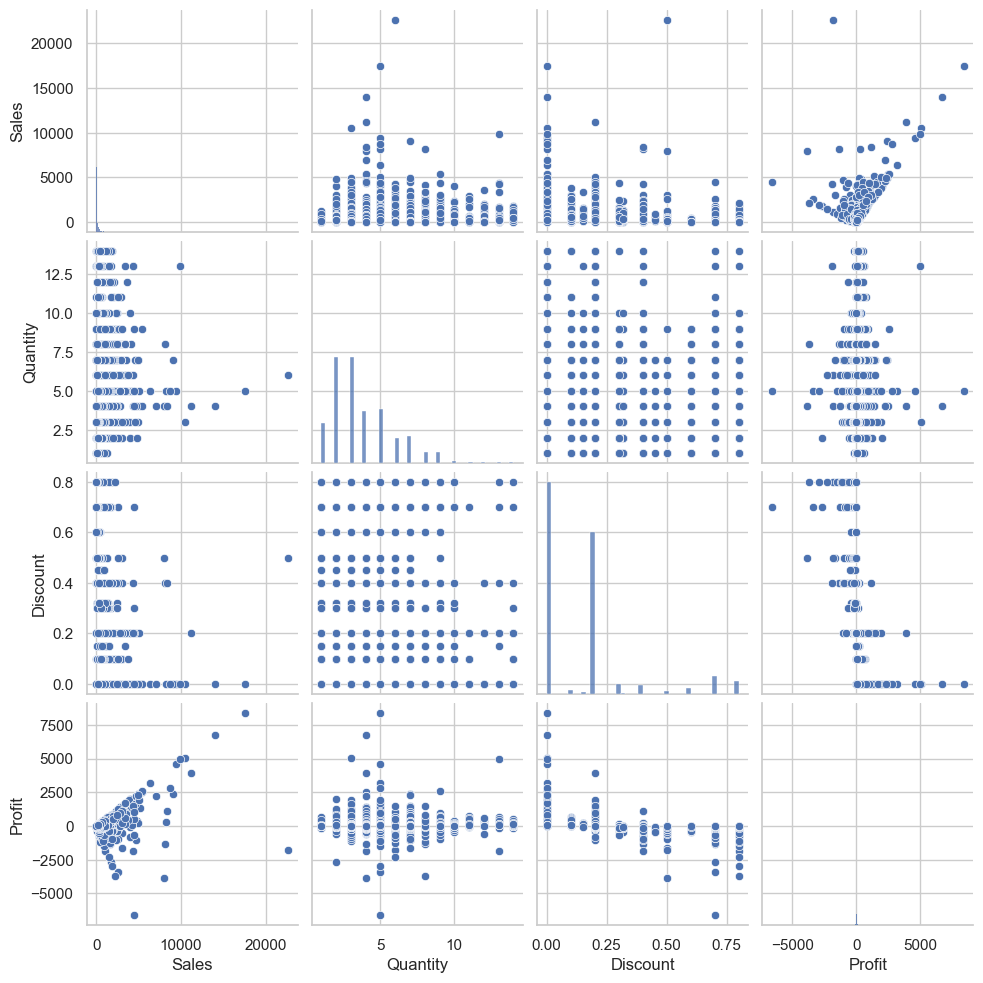

In [74]:
sns.pairplot(df[['Sales','Quantity','Discount','Profit']])
plt.show()


Correlation Analysis 

Study the relation between the numeric variables.

In [75]:
corr = df[['Sales','Quantity','Discount','Profit']].corr()
corr

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200722,-0.028311,0.479067
Quantity,0.200722,1.000000,0.008678,0.066211
Discount,-0.028311,0.008678,1.000000,-0.219662
Profit,0.479067,0.066211,-0.219662,1.000000


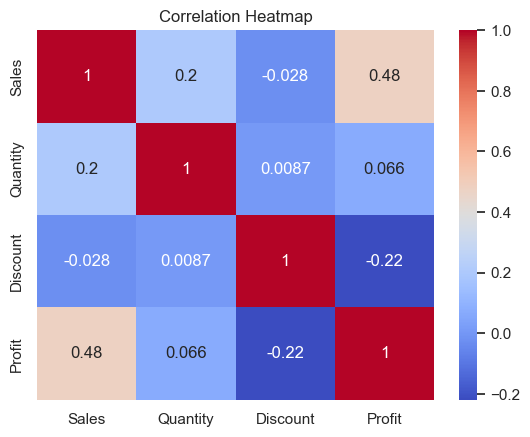

In [76]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [77]:
# How does discount relate to profit?
df.groupby('Discount')['Profit'].mean()

Discount
0.00     67.024108
0.10     96.055074
0.15     27.288298
0.20     24.721217
0.30    -45.828401
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -102.116395
Name: Profit, dtype: float64

Project Summary


Goal


To explore and understand the Superstore sales dataset using Exploratory Data Analysis (EDA).

To identify patterns and relationships in sales, profit, customers, products, regions, and discounts.

Key Findings


Standard Class is the most commonly used shipping mode.

Consumer is the largest customer segment.

Office Supplies has the highest number of orders.

Sales and Profit contain skewed distributions and some outliers.

Discounts and other business factors show relationships with profitability.
